# Разделение выборки и обучение базовой модели

В данном ноутбуке выполняется подготовка модельной выборки к обучению, разбиение данных по участникам без утечки информации, обучение базовой классификационной модели и оценка её качества.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from src.config import MODEL_DATA_PATH, RANDOM_STATE

In [2]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
model_df.head()

(47523, 82)


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [3]:
print(model_df.columns.tolist())
print(model_df["target_bad_sleep"].value_counts(normalize=True))

['SEQN', 'calendar_date', 'weekday', 'dayofweek', 'window_number', 'night_number', 'month', 'day', 'dayofyear', 'target_bad_sleep', 'sleep_efficiency_lag1', 'nonwear_perc_day_lag1', 'nonwear_perc_spt_lag1', 'nonwear_perc_day_spt_lag1', 'sleeponset_lag1', 'wakeup_lag1', 'L5VALUE_lag1', 'L5TIME_num_lag1', 'M5VALUE_lag1', 'M5TIME_num_lag1', 'L10VALUE_lag1', 'L10TIME_num_lag1', 'M10VALUE_lag1', 'M10TIME_num_lag1', 'dur_spt_sleep_min_lag1', 'dur_spt_wake_IN_min_lag1', 'dur_spt_wake_LIG_min_lag1', 'dur_spt_wake_MOD_min_lag1', 'dur_spt_wake_VIG_min_lag1', 'dur_day_min_lag1', 'dur_spt_min_lag1', 'dur_day_spt_min_lag1', 'ACC_spt_sleep_mg_lag1', 'excluded_lag1', 'sleep_efficiency_lag2', 'nonwear_perc_day_lag2', 'nonwear_perc_spt_lag2', 'nonwear_perc_day_spt_lag2', 'sleeponset_lag2', 'wakeup_lag2', 'L5VALUE_lag2', 'L5TIME_num_lag2', 'M5VALUE_lag2', 'M5TIME_num_lag2', 'L10VALUE_lag2', 'L10TIME_num_lag2', 'M10VALUE_lag2', 'M10TIME_num_lag2', 'dur_spt_sleep_min_lag2', 'dur_spt_wake_IN_min_lag2', 'du

## Train and test

In [4]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)
groups = model_df[group_col]

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

drop_cols = ["SEQN", "calendar_date"]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("Уникальных участников в train:", groups_train.nunique())
print("Уникальных участников в test :", groups_test.nunique())
print("Пересечение участников:", len(set(groups_train).intersection(set(groups_test))))

Train: (37976, 79) (37976,)
Test : (9547, 79) (9547,)
Уникальных участников в train: 10430
Уникальных участников в test : 2608
Пересечение участников: 0


In [7]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))

Categorical: ['weekday']
Numeric count: 78


In [8]:
X_train['weekday'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday',
       'Tuesday'], dtype=object)

## Собираем препроцессор
Для baseline-модели делаем:
- числовые признаки: медианная импутация + стандартизация;
- категориальные: заполнение модой + one-hot encoding.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [10]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

## Обучение модели

In [11]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Предсказания и метрики

In [12]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ROC-AUC :", round(roc_auc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

ROC-AUC : 0.7408
Precision: 0.5727
Recall   : 0.6264
F1-score : 0.5984


In [13]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7718    0.7300    0.7503      6051
           1     0.5727    0.6264    0.5984      3496

    accuracy                         0.6920      9547
   macro avg     0.6722    0.6782    0.6743      9547
weighted avg     0.6989    0.6920    0.6947      9547



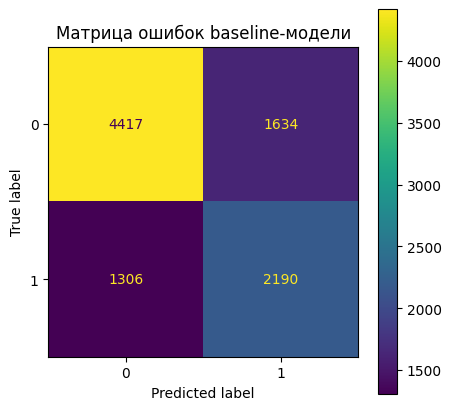

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.title("Матрица ошибок baseline-модели")
plt.show()

In [15]:
print("Train class balance:")
print(y_train.value_counts(normalize=True))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train class balance:
target_bad_sleep
0    0.626448
1    0.373552
Name: proportion, dtype: float64

Test class balance:
target_bad_sleep
0    0.633812
1    0.366188
Name: proportion, dtype: float64
